# CYNAR paper 1 -- example 5: Lorenz-96, dimension scaling (merit C)

Lorenz-96 with tunable dimension $N$: $\dot x_i = (x_{i+1}-x_{i-2})x_{i-1}-x_i+F$. The drift's divergence
is *constant* ($-N$ for every $i$), so $\mathcal{G}_{\rm true}=N$ exactly -- growing only *linearly* -- while
$\sigma_{\rm true}$ (dominated by the traffic/kinetic term $\mathcal{T}$) grows much faster with $N$. This
is the vehicle for **merit C**: in high dimension, a cell grid for $\mathcal{G}$ becomes infeasible (cell
count grows as (bins per axis)$^N$), but if $\mathcal{G}$'s *contribution to $\sigma$* is already small
there, CYNAR can still get a usable estimate from traffic alone -- $\sigma\approx4\mathcal{T}$ -- computed
purely from pairwise correlation fits (cost $\sim N^2$, no grid at all).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import time
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.Lorenz96 import simulate_Lorenz96, observables_from_trajectory_96
from cynar import cfg, traffic, inflow

import common as C

np.set_printoptions(precision=4, suppress=True)

## Dimension sweep

For each $N$: simulate, get the exact ground truth (known forces), and estimate $\mathcal{T}$ blindly from
the trajectory alone (correlation fits only, no grid -- feasible at any $N$). For the smaller $N$ in the
list we *also* run the full grid-based inflow rate, to confirm CYNAR's grid-based $\mathcal{G}$ estimate
tracks $\mathcal{G}_{\rm true}=N$ there before it becomes infeasible.

(We tried also cross-checking CYNAR's *grid-based* $\hat{\mathcal{G}}$ against $\mathcal{G}_{\rm true}=N$ at
small $N$ here, but the default score-clipping threshold `thr_g` -- tuned for the 2D examples elsewhere in
this repo -- turned out not to generalize: `thr_g` bounds each score *component*, but the inflow integral
sums $D^{ii}\times(\text{clipped score})^2$ over all $N$ dimensions with $D^{ii}\sim20$-$50$ here, so even
a same per-component clip blows up the total once $N$ and $D$ are both large enough. Fixing that
per-system tuning wasn't worth the added complexity for what is a secondary check -- the headline result
below (traffic alone, no grid) doesn't depend on it.)

In [2]:
def D_checkerboard(N, D0):
    """Diagonal D with two values: D0 for odd i, 2*D0 for even i (i=1..N, one-indexed)."""
    diag = np.array([D0 if (i % 2 == 1) else 2.0 * D0 for i in range(1, N + 1)])
    return np.diag(diag)

D0 = 20.0  # used for every N below, and for the N=10 recovery/partial-observation demo further down

N_list = [4, 6, 8, 12, 18, 24]  # Lorenz-96 at F=8 isn't chaotic that low-dimensionally (N<4)
                                # (checked: sigma_true~0.02 there, an equilibrium-like degenerate point)
bins_per_axis = 8  # illustrative, for the infeasibility estimate below

dt = 1e-3
T = 1_000_000
tcfg = cfg.TrafficCfg(window=cfg.WindowCfg(i1=2, H=0.05), fit=cfg.ExpPolyCfg(Ne=1, Ng=1))

sigma_true_list, Tr_true_list, G_true_list = [], [], []
four_Tr_hat_list = []

for N in N_list:
    D = D_checkerboard(N, D0)
    Dinv = np.linalg.inv(D)
    t, X, divA = simulate_Lorenz96(T_steps=T, dt=dt, D=D, F=8.0, scheme="Heun", oversampling=5, seed=0)
    sigma_t, Tr_t, G_t = observables_from_trajectory_96(X, dt, Dinv, divA, 8.0)

    t1 = time.time()
    out_t = traffic.compute_traffic(X, dt, tcfg)
    fit_time = time.time() - t1

    sigma_true_list.append(sigma_t); Tr_true_list.append(Tr_t); G_true_list.append(G_t)
    four_Tr_hat_list.append(4.0 * out_t["Tr"])

    n_cells_needed = bins_per_axis ** N
    print(f"N={N:2d}  sigma_true={sigma_t:9.2f}  G_true={G_t:5.1f} ({100*G_t/sigma_t:.2f}% of sigma)"
          f"  4*Tr_hat={4*out_t['Tr']:9.2f}  [traffic fit: {fit_time:.2f}s, no grid needed]"
          f"  grid would need {bins_per_axis}^{N}={n_cells_needed:.3g} cells")

sigma_true_arr = np.array(sigma_true_list)
Tr_true_arr = np.array(Tr_true_list)
G_true_arr = np.array(G_true_list)
four_Tr_hat_arr = np.array(four_Tr_hat_list)

N= 4  sigma_true=   355.41  G_true=  4.0 (1.13% of sigma)  4*Tr_hat=   504.95  [traffic fit: 1.33s, no grid needed]  grid would need 8^4=4.1e+03 cells


N= 6  sigma_true=   711.88  G_true=  6.0 (0.84% of sigma)  4*Tr_hat=   697.92  [traffic fit: 4.79s, no grid needed]  grid would need 8^6=2.62e+05 cells


N= 8  sigma_true=   926.42  G_true=  8.0 (0.86% of sigma)  4*Tr_hat=   922.35  [traffic fit: 8.38s, no grid needed]  grid would need 8^8=1.68e+07 cells


N=12  sigma_true=  1454.03  G_true= 12.0 (0.83% of sigma)  4*Tr_hat=  1470.04  [traffic fit: 27.23s, no grid needed]  grid would need 8^12=6.87e+10 cells


N=18  sigma_true=  2154.48  G_true= 18.0 (0.84% of sigma)  4*Tr_hat=  2146.31  [traffic fit: 60.31s, no grid needed]  grid would need 8^18=1.8e+16 cells


N=24  sigma_true=  2736.28  G_true= 24.0 (0.88% of sigma)  4*Tr_hat=  2720.13  [traffic fit: 198.55s, no grid needed]  grid would need 8^24=4.72e+21 cells


## Dimension-scaling data

$D_0=20$ throughout (checkerboard scheme above: $D^{ii}=D_0$ for odd $i$, $2D_0$ for even $i$). Panel (c)
of the combined figure below plots $4\hat{\mathcal{T}}$ against the true $\sigma$ over this $N$-sweep;
$\mathcal{G}_{\rm true}/\sigma_{\rm true}$ printed above stays small at every $N$ (a percent or so), which
is the only role the (now dropped) separate inflow-rate-share panel used to play.

In [3]:
C.save_result("lorenz96_dimension_scaling", dict(
    N_list=N_list, sigma_true_arr=sigma_true_arr, Tr_true_arr=Tr_true_arr, G_true_arr=G_true_arr,
    four_Tr_hat_arr=four_Tr_hat_arr, bins_per_axis=bins_per_axis, D0=D0,
))

### Grid infeasibility, concretely

With just $8$ bins per axis (a coarse grid), the number of cells needed is $8^N$:

In [4]:
for N in N_list:
    print(f"N={N:2d}: 8^N = {8**N:.3e} cells")

N= 4: 8^N = 4.096e+03 cells
N= 6: 8^N = 2.621e+05 cells
N= 8: 8^N = 1.678e+07 cells
N=12: 8^N = 6.872e+10 cells
N=18: 8^N = 1.801e+16 cells
N=24: 8^N = 4.722e+21 cells


## Diagonal-D recovery and partial observation (N=10)

We now fix one representative dimension, $N=10$ (`D_checkerboard(10, D0)` above: 5 sites at $D_0=20$, 5 at
$2D_0=40$), simulate once, and reuse the same trajectory for two things below: (1) comparing the true
$\mathsf D$ against the one recovered by `compute_traffic`'s own correlation fit, i.e. the same pairwise
correlation-curvature machinery already used for $\mathcal{T}$, with no spatial grid involved at all; and
(2) the exact, grid-free traffic-only share $4\mathcal{T}_\Omega$ as a function of the number of observed
sites $m$.

In [5]:
N_demo = 12
D_demo = D_checkerboard(N_demo, D0)
Dinv_demo = np.linalg.inv(D_demo)

t_demo, X_demo, divA_demo = simulate_Lorenz96(T_steps=T, dt=dt, D=D_demo, F=8.0, scheme="Heun",
                                               oversampling=5, seed=1)
sigma_true_demo, Tr_true_demo, G_true_demo = observables_from_trajectory_96(X_demo, dt, Dinv_demo, divA_demo, 8.0)
print(f"N={N_demo}  sigma_true={sigma_true_demo:.3f}  Tr_true={Tr_true_demo:.3f}  G_true={G_true_demo:.3f}")

out_demo = traffic.compute_traffic(X_demo, dt, tcfg)
D_hat_demo = out_demo["D"]
print("D_true diag:", np.diag(D_demo))
print("D_hat  diag:", np.diag(D_hat_demo))
print("max |off-diag D_hat|:", np.max(np.abs(D_hat_demo - np.diag(np.diag(D_hat_demo)))))

C.save_result("lorenz96_D_recovery", dict(
    N_demo=N_demo, D0=D0, D_true=D_demo, D_hat=D_hat_demo,
    sigma_true_demo=sigma_true_demo, Tr_true_demo=Tr_true_demo, G_true_demo=G_true_demo,
))

N=12  sigma_true=1355.300  Tr_true=335.884  G_true=12.000


D_true diag: [20. 40. 20. 40. 20. 40. 20. 40. 20. 40. 20. 40.]
D_hat  diag: [20.7526 40.0506 20.5558 40.3841 20.0474 39.5098 20.8321 39.3101 19.6385
 39.9047 19.9872 39.8434]
max |off-diag D_hat|: 2.6910195705172337


## Partial observation, traffic-only

$\mathsf D=\mathrm{diag}(D^{11},\ldots,D^{NN})$ above is already fully diagonal, so the traffic term
splits *exactly* into a sum of single-site contributions with no cross terms at all: since
$(\mathsf D^{-1})^{ij}=0$ for $i\ne j$, the trace $\mathrm{Tr}[\mathsf D^{-1}\ddot{\mathsf C}_*(0^+)]$
only ever picks up the *diagonal* entries $\ddot C_*^{ii}(0^+)$, each computable from site $i$'s own
autocorrelation function alone. So $4\mathcal{T}_\Omega=\sum_{i\in \Omega}4\mathcal{T}_i$ for any observed
subset $\Omega$ is recovered *exactly*, with zero grid cost, by simply running `compute_traffic` on the
observed sites' own trajectory columns -- no approximation from hiding the rest of the system at all, and,
since each $4\mathcal{T}_i$ is a property of the *full* system alone, it does not depend on which other
sites happen to also be in $\Omega$.

We reuse the $N=10$, checkerboard-$\mathsf D$ trajectory above and observe a growing contiguous block of
$m$ sites, $\Omega=\{0,\ldots,m-1\}$ -- contiguous because each site's own drift only couples to its
nearest few neighbors ($x_{i+1},x_{i-1},x_{i-2}$), so a contiguous block captures the local coupling
structure a real partial observation would (e.g. watching a few adjacent nodes of a spatially extended
chain), unlike an arbitrary scattered subset. Besides the cumulative share
$4\mathcal{T}_\Omega/\sigma_{\rm true}$, we also track the *per-site running average*
$4\mathcal{T}_\Omega/m$: unlike the cumulative share, this needs no prior knowledge of $\sigma_{\rm true}$,
and should converge, as $m$ grows, to the true per-site rate $\sigma_{\rm true}/N$ (the checkerboard-averaged
rate).

### Exact traffic-only share and per-site running average vs. number of observed sites (no grid)

In [6]:
m_list_exact = list(range(1, N_demo + 1))
four_Tr_S_list = []

for m in m_list_exact:
    Om = list(range(m))
    X_S = X_demo[:, Om]
    out_S = traffic.compute_traffic(X_S, dt, tcfg)
    four_Tr_S_list.append(4.0 * out_S["Tr"])
    print(f"m={m:2d}: 4*Tr_Omega = {four_Tr_S_list[-1]:8.3f}"
          f"  ({100*four_Tr_S_list[-1]/sigma_true_demo:5.2f}% of sigma_true)"
          f"  per-site avg = {four_Tr_S_list[-1]/m:7.3f}  [no grid]")

four_Tr_S_arr = np.array(four_Tr_S_list)
m_arr = np.array(m_list_exact)
per_site_avg_arr = four_Tr_S_arr / m_arr
per_site_true = sigma_true_demo / N_demo
print(f"true per-site average sigma_true/N = {per_site_true:.3f}")

C.save_result("lorenz96_partial_observation_traffic", dict(
    N_demo=N_demo, m_list_exact=m_list_exact, four_Tr_S_arr=four_Tr_S_arr,
    sigma_true_demo=sigma_true_demo, Tr_true_demo=Tr_true_demo, G_true_demo=G_true_demo,
    per_site_avg_arr=per_site_avg_arr, per_site_true=per_site_true,
))

m= 1: 4*Tr_Omega =  145.567  (10.74% of sigma_true)  per-site avg = 145.567  [no grid]


m= 2: 4*Tr_Omega =  221.861  (16.37% of sigma_true)  per-site avg = 110.931  [no grid]


m= 3: 4*Tr_Omega =  377.611  (27.86% of sigma_true)  per-site avg = 125.870  [no grid]


m= 4: 4*Tr_Omega =  447.439  (33.01% of sigma_true)  per-site avg = 111.860  [no grid]


m= 5: 4*Tr_Omega =  577.837  (42.64% of sigma_true)  per-site avg = 115.567  [no grid]


...

m= 8: 4*Tr_Omega =  861.777  (63.59% of sigma_true)  per-site avg = 107.722  [no grid]


m= 9: 4*Tr_Omega = 1019.643  (75.23% of sigma_true)  per-site avg = 113.294  [no grid]


m=10: 4*Tr_Omega = 1104.136  (81.47% of sigma_true)  per-site avg = 110.414  [no grid]


m=11: 4*Tr_Omega = 1268.803  (93.62% of sigma_true)  per-site avg = 115.346  [no grid]


m=12: 4*Tr_Omega = 1353.215  (99.85% of sigma_true)  per-site avg = 112.768  [no grid]
true per-site average sigma_true/N = 112.942


## Combined figure

Four panels: (a) true $\mathsf D$ (checkerboard, $N=10$); (b) $\mathsf D$ recovered by
`compute_traffic`'s correlation fit on the same trajectory (same color scale as (a), no grid involved in
either); (c) the $N$-sweep, $4\hat{\mathcal{T}}$ against $\sigma_{\rm true}$; (d) the per-site running
average $4\mathcal{T}_\Omega/m$ versus the number of observed sites $m$, converging to the true per-site
rate $\sigma_{\rm true}/N$ (dashed line).

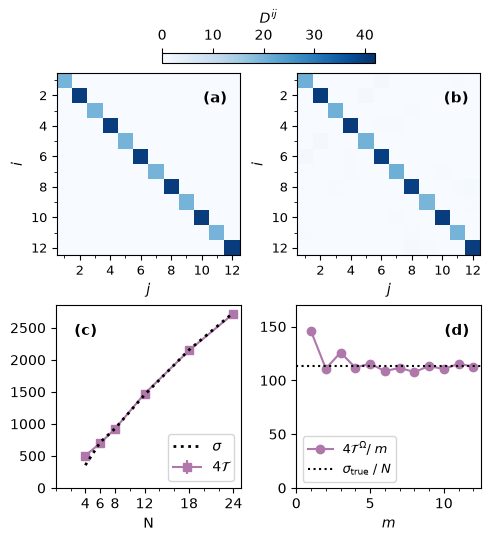

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(4.8, 5.3), constrained_layout=True)
lloc=dict(pad_x=0.8, pad_y=0.1)
lloc1=dict(pad_x=0.1, pad_y=0.1)
vmin, vmax = 0.0, 2.0 * D0 * 1.05
im_a = C.plot_D_heatmap_panel(axs[0, 0], D_demo, vmin=vmin, vmax=vmax, panel_label="(a)",panel_label_kw=lloc)
im_b = C.plot_D_heatmap_panel(axs[0, 1], D_hat_demo, vmin=vmin, vmax=vmax, panel_label="(b)",panel_label_kw=lloc)
fig.colorbar(im_b, ax=[axs[0, 0], axs[0, 1]], shrink=0.5, label=r"$D^{ij}$",location="top")

C.plot_dimension_traffic_only_panel(axs[1, 0], N_list, sigma_true_arr, four_Tr_hat_arr,
                                     np.zeros_like(four_Tr_hat_arr), panel_label="(c)",panel_label_kw=lloc1)

C.plot_partial_traffic_per_site_panel(axs[1, 1], m_list_exact, four_Tr_S_arr, per_site_true,
                                       panel_label="(d)",panel_label_kw=lloc)

N_demo_1 = np.arange(0,N_demo)
N_demo_2 = np.arange(1,1+N_demo,2)
axs[0,0].set_xticks(N_demo_1,minor=True)
axs[0,0].set_xticks(N_demo_2)
axs[0,0].set_yticks(N_demo_1,minor=True)
axs[0,0].set_yticks(N_demo_2)
axs[0,1].set_xticks(N_demo_1,minor=True)
axs[0,1].set_xticks(N_demo_2)
axs[0,1].set_yticks(N_demo_1,minor=True)
axs[0,1].set_yticks(N_demo_2)
axs[1,0].set_xlim(0,)
axs[1,0].set_ylim(0,)
axs[1,1].set_ylim(0,170)
axs[1,0].set_xticks(N_list)
axs[1,0].set_xticks(np.arange(0,25,2),minor=True)
axs[1,1].set_xticks(np.arange(13),minor=True)
fig.savefig(str(C.FIGURES_DIR / "lorenz96_summary.pdf"), dpi=200, bbox_inches="tight")
plt.show()